LAE COLOR-COLOR TRACKS WITH DECam FILTERS

----------------------------------------
LOADING FILTERS
----------------------------------------
Loading filter: /Users/aishwarya/Downloads/CTIO_DECam.i.dat
  Raw wavelength range: 6750.0 - 8700.0
  Corrected wavelength range: 6750.0 - 8700.0
Loading filter: /Users/aishwarya/Downloads/CTIO_DECam.z.dat
  Raw wavelength range: 8250.0 - 10150.0
  Corrected wavelength range: 8250.0 - 10150.0
Loading filter: //Users/aishwarya/Downloads/CTIO_DECam.Y.dat
  Raw wavelength range: 9300.0 - 10700.0
  Corrected wavelength range: 9300.0 - 10700.0

Final filter wavelength ranges:
  i-filter: 6750 - 8700 Å
  z-filter: 8250 - 10150 Å
  y-filter: 9300 - 10700 Å

----------------------------------------
LOADING SED TEMPLATES
----------------------------------------
Loading SED: /Users/aishwarya/Downloads/swire_library/M82_template_norm.sed
  Raw wavelength range: 1005 - 60460000
  Cleaned: 1215 points
Loading SED: /Users/aishwarya/Downloads/swire_library/QSO2_

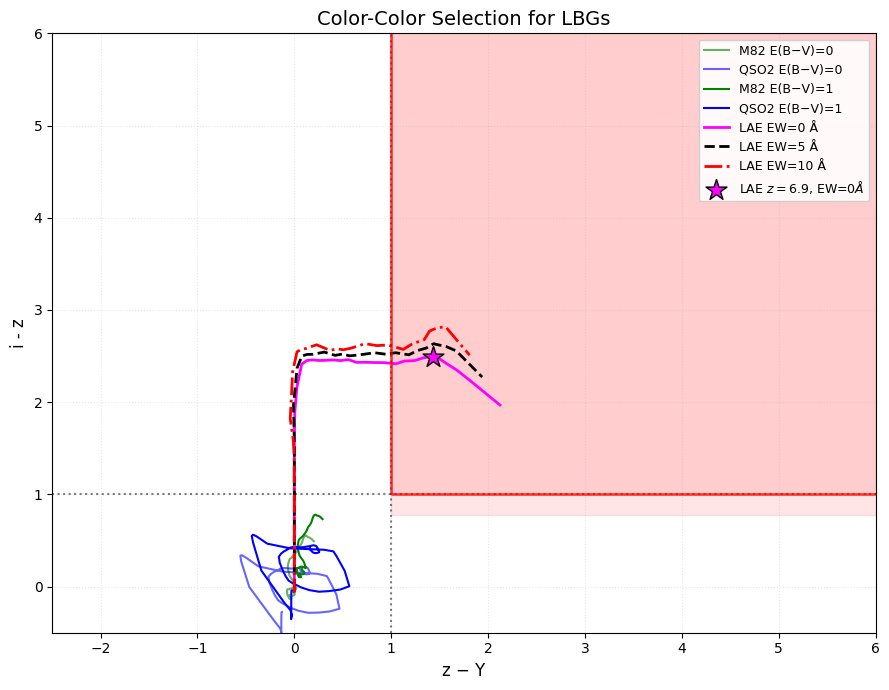


PLOT GENERATION COMPLETE


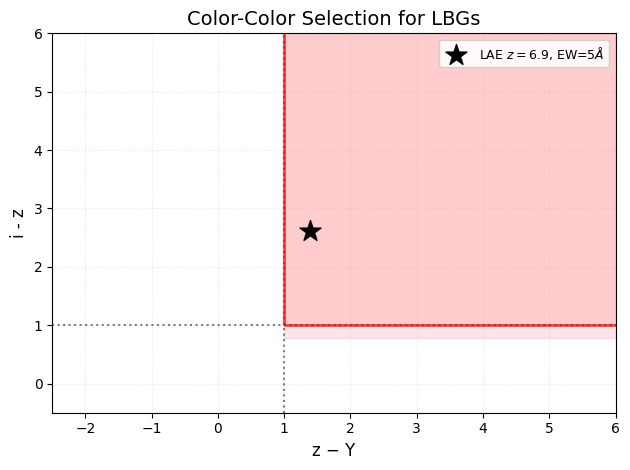


PLOT GENERATION COMPLETE


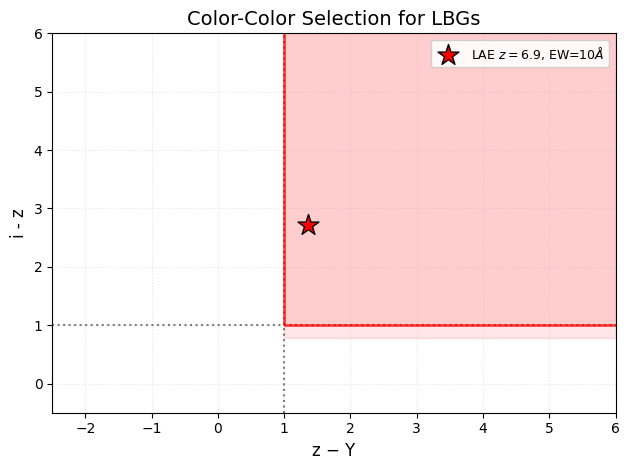

In [9]:
"""
Color–color tracks for LAE selection using DECam filters
LAEs + low-z interlopers (M82, QSO2)

NO custom packages
ONLY numpy, matplotlib, astropy, synphot
"""

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from synphot import (
    SourceSpectrum,
    SpectralElement,
    Observation,
    Empirical1D,
    etau_madau,
    ReddeningLaw
)
import synphot.units as su




def load_filter(filename, check_wavelengths=True):
    """Load filter transmission curve with proper unit handling."""
    print(f"Loading filter: {filename}")
    
    # Load data
    data = np.loadtxt(filename)
    
    # Check shape
    if data.shape[1] == 2:
        wave = data[:, 0]
        thr = data[:, 1]
    else:
        # Try different format
        wave = data
        thr = np.ones_like(wave)
    
    # Check wavelength range - NB964 should be around 9640 Å
    print(f"  Raw wavelength range: {wave.min():.1f} - {wave.max():.1f}")
    
    # Fix NB964 filter if needed
    """if 'NB964' in filename and wave.max() < 2000:
        print(f"  WARNING: NB964 wavelengths look too small ({wave.max():.1f}).")
        print(f"  Multiplying by 10 to convert nm to Å...")
        wave = wave * 10  # Convert nm to Å"""
    
    print(f"  Corrected wavelength range: {wave.min():.1f} - {wave.max():.1f}")
    
    return SpectralElement(
        Empirical1D,
        points=wave * u.angstrom,
        lookup_table=thr,
        keep_neg=False,
    )


def load_sed(filename):
    """Load SED template and clean duplicates."""
    wave, flux = np.loadtxt(filename, unpack=True)
    
    print(f"Loading SED: {filename}")
    print(f"  Raw wavelength range: {wave.min():.0f} - {wave.max():.0f}")
    
    # Check if flux is F_nu or F_lambda
    # SEDs from Polletta are typically in F_nu (Jy)
    flux = flux * su.FNU  # Assume F_nu
    
    # Remove duplicates and sort
    wave_unique, idx = np.unique(wave, return_index=True)
    wave_unique = wave_unique * u.angstrom
    flux_unique = flux[idx]
    
    # Sort
    sort_idx = np.argsort(wave_unique.value)
    wave_sorted = wave_unique[sort_idx]
    flux_sorted = flux_unique[sort_idx]
    
    print(f"  Cleaned: {len(wave_sorted)} points")
    
    return SourceSpectrum(
        Empirical1D,
        points=wave_sorted,
        lookup_table=flux_sorted,
        keep_neg=True,
    )


def create_interloper_spectrum(sed, z, ebv=0):
    """Create redshifted spectrum for an interloper."""
    # Create a simple redshifted spectrum using the SED model
    spec_z = SourceSpectrum(sed.model, z=z, z_type='conserve_flux')
    
    # Apply IGM absorption
    if z > 0:
        extinction_curve = etau_madau(spec_z.waveset, z)
        spec_z = spec_z * extinction_curve
    
    # Apply dust extinction if needed
    if ebv > 0:
        try:
            extinction_curve = ReddeningLaw.from_extinction_model('xgalsb').extinction_curve(ebv)
            spec_z = spec_z * extinction_curve
        except:
            # Fallback to simple Calzetti
            wave = spec_z.waveset.to(u.angstrom).value
            k = (wave / 5500.0) ** -0.7
            attenuation = 10 ** (-0.4 * ebv * k)
            
            dust_filter = SpectralElement(
                Empirical1D,
                points=spec_z.waveset,
                lookup_table=attenuation,
            )
            spec_z = spec_z * dust_filter
    
    return spec_z


def create_lae_spectrum(z, ew_lya=50*u.angstrom):
    """Create LAE spectrum at redshift z (simplified version)."""
    # Wavelength range covering all filters
    wave_min = 6000  # Å
    wave_max = 12000  # Å
    wave_obs = np.linspace(wave_min, wave_max, 1000) * u.angstrom
    
    # Lyα line position
    lya_rest = 1215.67 * u.angstrom
    lya_obs = lya_rest * (1 + z)
    
    # Create continuum (flat)
    continuum = 1e-30 * su.FNU
    
    # Add Gaussian line
    sigma = 10.0 * u.angstrom  # Broader line for visibility
    line = np.exp(-(wave_obs - lya_obs)**2 / (2 * sigma**2))
    
    # Scale line by equivalent width
    line_flux = continuum.value * ew_lya.to(u.angstrom).value * line / np.max(line)
    
    # Total flux
    flux_total = continuum.value + line_flux
    
    # Create spectrum
    spec = SourceSpectrum(
        Empirical1D,
        points=wave_obs,
        lookup_table=flux_total * continuum.unit,
        keep_neg=True,
    )
    
    # Apply IGM absorption
    if z > 0:
        extinction_curve = etau_madau(spec.waveset, z)
        spec = spec * extinction_curve
    
    return spec


def compute_magnitude(spectrum, filt, z=None):
    """Compute AB magnitude through filter with debugging."""
    # Check wavelength overlap
    spec_min = spectrum.waveset.min().value
    spec_max = spectrum.waveset.max().value
    filt_min = filt.waveset.min().value
    filt_max = filt.waveset.max().value
    
    if spec_max < filt_min or spec_min > filt_max:
        print(f"    No overlap: spec={spec_min:.0f}-{spec_max:.0f} Å, "
              f"filt={filt_min:.0f}-{filt_max:.0f} Å")
        return None
    
    try:
        obs = Observation(spectrum, filt, force="taper")
        mag = obs.effstim(u.ABmag)
        return mag
    except Exception as e:
        print(f"    Magnitude computation error: {str(e)[:50]}")
        return None


def compute_color_track(spec_func, z_grid, f_i, f_z, f_y, name="Track"):
    """Compute color track for a spectrum function with debugging."""
    print(f"\nComputing {name} track...")
    iz = []
    zy = []
    
    for i, z in enumerate(z_grid):
        if i % 20 == 0:
            print(f"  z={z:.2f}: ", end="")
        
        spec = spec_func(z)
        
        # Check spectrum wavelength range
        spec_min = spec.waveset.min().value
        spec_max = spec.waveset.max().value
        
        if i % 20 == 0:
            print(f"spec={spec_min:.0f}-{spec_max:.0f} Å")
        
        mi = compute_magnitude(spec, f_i, z)
        mz = compute_magnitude(spec, f_z, z)
        my = compute_magnitude(spec, f_y, z)
        
        if mi is None or mz is None or my is None:
            iz.append(np.nan)
            zy.append(np.nan)
            if i % 20 == 0:
                print(f"    Failed to compute all magnitudes")
        else:
            iz_val = (mi - mz).value
            zy_val = (mz - my).value
            iz.append(iz_val)
            zy.append(zy_val)
            if i % 20 == 0:
                print(f"    i-z={iz_val:.2f}, z-y={zy_val:.2f}")

    iz = np.array(iz)
    zy = np.array(zy)

    valid = ~np.isnan(iz) & ~np.isnan(zy)
    print(f"  Valid points: {valid.sum()}/{len(z_grid)}")

    return iz, zy




if __name__ == "__main__":
    
    print("=" * 60)
    print("LAE COLOR-COLOR TRACKS WITH DECam FILTERS")
    print("=" * 60)
    
    # File paths
    FILTER_I_FILE = "/Users/aishwarya/Downloads/CTIO_DECam.i.dat"
    FILTER_Z_FILE = "/Users/aishwarya/Downloads/CTIO_DECam.z.dat"
    FILTER_Y_FILE = "//Users/aishwarya/Downloads/CTIO_DECam.Y.dat"
    
    M82_SED_FILE = "/Users/aishwarya/Downloads/swire_library/M82_template_norm.sed"
    QSO2_SED_FILE = "/Users/aishwarya/Downloads/swire_library/QSO2_template_norm.sed"
    
    # Load filters
    print("\n" + "-" * 40)
    print("LOADING FILTERS")
    print("-" * 40)
    f_i = load_filter(FILTER_I_FILE)
    f_z = load_filter(FILTER_Z_FILE)
    f_y = load_filter(FILTER_Y_FILE)
    
    # Print filter ranges
    print(f"\nFinal filter wavelength ranges:")
    print(f"  i-filter: {f_i.waveset.min().value:.0f} - {f_i.waveset.max().value:.0f} Å")
    print(f"  z-filter: {f_z.waveset.min().value:.0f} - {f_z.waveset.max().value:.0f} Å")
    print(f"  y-filter: {f_y.waveset.min().value:.0f} - {f_y.waveset.max().value:.0f} Å")
    
    # Load SEDs
    print("\n" + "-" * 40)
    print("LOADING SED TEMPLATES")
    print("-" * 40)
    sed_m82 = load_sed(M82_SED_FILE)
    sed_qso2 = load_sed(QSO2_SED_FILE)
    
    # Redshift ranges
    z_low = np.arange(0.0, 1.31, 0.02)  # Coarser sampling for speed
    z_lae = np.arange(4.0, 7.2, 0.05)
    
    # Create plot
    plt.figure(figsize=(9, 7))
    
    # Plot interlopers
    print("\n" + "-" * 40)
    print("COMPUTING INTERLOPER TRACKS")
    print("-" * 40)
    
    for ebv, alpha in [(0, 0.6), (1, 1.0)]:
        # M82
        iz, zy = compute_color_track(
            lambda z, s=sed_m82, e=ebv: create_interloper_spectrum(s, z, e),
            z_low, f_i, f_z, f_y, name=f"M82 E(B-V)={ebv}"
        )
        
        valid = ~np.isnan(iz) & ~np.isnan(zy)
        if np.any(valid):
            plt.plot( zy[valid],iz[valid], color="green", alpha=alpha,
                    lw=1.5, label=f"M82 E(B−V)={ebv}")
        
        # QSO2
        iz, zy = compute_color_track(
            lambda z, s=sed_qso2, e=ebv: create_interloper_spectrum(s, z, e),
            z_low, f_i, f_z, f_y, name=f"QSO2 E(B-V)={ebv}"
        )
        
        valid = ~np.isnan(iz) & ~np.isnan(zy)
        if np.any(valid):
            plt.plot(zy[valid],iz[valid],  color="blue", alpha=alpha,
                    lw=1.5, label=f"QSO2 E(B−V)={ebv}")
    
    # Plot LAEs
    print("\n" + "-" * 40)
    print("COMPUTING LAE TRACKS")
    print("-" * 40)
    
    for ew, col, style in [(0*u.angstrom, "magenta", "-"),
                          (5*u.angstrom, "black", "--"),
                          (10*u.angstrom, "red", "-.")]:
        
        iz, zy = compute_color_track(
            lambda z, e=ew: create_lae_spectrum(z, e),
            z_lae, f_i, f_z, f_y, name=f"LAE EW={ew.value}Å"
        )
        
        valid = ~np.isnan(iz) & ~np.isnan(zy)
        if np.any(valid):
            plt.plot(zy[valid], iz[valid], lw=2, color=col, linestyle=style,
                    label=f"LAE EW={ew.value:.0f} Å")
    # --- Star at z = 6.9 ---
  
z_star = 6.9

ew_list = [
    (0 * u.angstrom, "magenta"),
    (5 * u.angstrom, "black"),
    (10 * u.angstrom, "red"),
]

for ew, col in ew_list:
    spec_star = create_lae_spectrum(z_star, ew)

    mi = compute_magnitude(spec_star, f_i)
    mz = compute_magnitude(spec_star, f_z)
    my = compute_magnitude(spec_star, f_y)

    if mi is None or mz is None or my is None:
        continue

    iz_star = (mi - mz).value
    zy_star = (mz - my).value

    plt.scatter(
        zy_star, iz_star,
        marker='*',
        s=250,
        color=col,
        edgecolor='k',
        zorder=20,
        label=fr'LAE $z=6.9$, EW={ew.value:.0f}$\AA$'
    )



    # Selection box and formatting
    # Selection cuts: i-z > 1, z-Y > 1
    plt.axvline(1.0, ls=":", color="k", alpha=0.5)
    plt.axhline(1.0, ls=":", color="k", alpha=0.5)

    plt.vlines(1.0, 1.0, 6, color="red", lw=2, alpha=0.7)
    plt.hlines(1.0, 1.0, 6, color="red", lw=2, alpha=0.7)

    plt.fill_between([1.0, 6], 1.0, 6, color='red', alpha=0.1)

    # Fill selection box
    plt.fill_between([1.0, 6], 0.78, 6, color='red', alpha=0.1)
    
    plt.xlim(-2.5, 6)   # z − Y
    plt.ylim(-0.5, 6)   # i − z

    plt.xlabel("z − Y", fontsize=12)
    plt.ylabel("i - z", fontsize=12)
    plt.title("Color-Color Selection for LBGs", fontsize=14)
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.legend(frameon=True, framealpha=0.9, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    
    print("\n" + "=" * 60)
    print("PLOT GENERATION COMPLETE")
    print("=" * 60)
    
    plt.show()